## Chapter 13 - Applied

In [119]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP import load_data

In [120]:
# New imports
from scipy.stats import (
    ttest_1samp,
    ttest_rel,
    ttest_ind,
    t,
)
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests as mult_test

### Question 7

#### 7a)

In [121]:
# Load dataset Carseats
carseats = pd.read_csv('data/Carseats.csv')
carseats.columns = [x.lower() for x in carseats.columns]
carseats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sales        400 non-null    float64
 1   compprice    400 non-null    int64  
 2   income       400 non-null    int64  
 3   advertising  400 non-null    int64  
 4   population   400 non-null    int64  
 5   price        400 non-null    int64  
 6   shelveloc    400 non-null    object 
 7   age          400 non-null    int64  
 8   education    400 non-null    int64  
 9   urban        400 non-null    object 
 10  us           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


In [122]:
# Create endogenous & exogenous variables
X = carseats.drop(columns=['sales', 'shelveloc', 'urban', 'us'])
y = carseats['sales']

# Add intercept
X.insert(0, 'intercept', np.ones(X.shape[0]))

In [123]:
# Create linear regressions & capture coefs p-values
coefs_pvalues = []
for var in range(1, X.shape[1]):
    X_ = X.iloc[:, [0, var]]
    model = sm.OLS(y, X_)
    results = model.fit()
    coefs_pvalues.append(round(results.f_pvalue, 5))

In [124]:
# Create & show coefs p-values dataframe
coefs_names = X.columns[1:]
coefs_pvalues_df = pd.DataFrame({
    'coefs': coefs_names,
    'p_values': coefs_pvalues
})
coefs_pvalues_df

,coefs,p_values
0,compprice,0.20094
1,income,0.00231
2,advertising,0.00000
3,population,0.31398
4,price,0.00000
5,age,0.00000
6,education,0.29994


#### 7b)

In [125]:
# Reject null hypothesis at alpha=0.05
alpha = 0.05
coefs_null_rejected = coefs_pvalues_df[
    coefs_pvalues_df['p_values'] <= alpha
].copy()
coefs_null_rejected

,coefs,p_values
1,income,0.00231
2,advertising,0.00000
4,price,0.00000
5,age,0.00000


We reject these coefficients being equal to zero at $\alpha=0.05$.

#### 7c)

#### <u>Bonferroni Method </u>

The Bonferroni Method is a simple and straight forward approach to control the family-wise error rate (FWER), which is the probability of making at least one Type I error across multiple comparisons. It does so by adjusting the significance level for each individual hypothesis test to $\frac{\alpha}{m}$, where $\alpha$ is your significance level and $m$ is the total number of hypotheses being tested.

In [126]:
# Set the Bonferroni control
alpha = 0.05
m = len(coefs_pvalues)
bonferroni_threshold = alpha / m

# Filter the coefficients using Bonferroni's method
coefs_bonferroni = coefs_pvalues_df[
    coefs_pvalues_df['p_values'] <= bonferroni_threshold
].copy()

# Show coefs
coefs_bonferroni

,coefs,p_values
1,income,0.00231
2,advertising,0.00000
4,price,0.00000
5,age,0.00000


In [127]:
# Print the bonferroni_threshold
print(round(bonferroni_threshold, 4))

0.0071


After applying the Benferroni's method, a conservative approach for controlling the FWER, we arrive at the same set of significant features as when using a standard significance level of $\alpha = 0.05$. 

Although the adjusted threshold, now set at 0.0071, is much lower than 0.05, the same four features still have p-values below this threshold.

#### <u>Holm's Step-Down Method </u>

Holm's method is a stepwise alternative to the Bonferroni procedure that is less conservative, meaning it offers more power while still controlling the family-wise error rate (FWER).

Given this, we would expect the same four features to remain significant, since Holm's adjusted thresholds are less strict than Bonferroni's but still lower than the overal significance level of $\alpha = 0.05$.

In [128]:
# Sort dataframe based on p-values
coefs_pvalues_df_sorted = coefs_pvalues_df.sort_values(by='p_values')

# Holm's thresholds
alpha = 0.05
m = coefs_pvalues_df_sorted.shape[0]
holm_threshold = [round((alpha / (m - i)), 5) for i in range(m)]

# Add threshold & filter dataframe
coefs_pvalues_df_sorted['holm_thresholds'] = holm_threshold
coefs_holm = coefs_pvalues_df_sorted[
    coefs_pvalues_df_sorted['p_values'] < coefs_pvalues_df_sorted['holm_thresholds']
].copy()
coefs_holm

,coefs,p_values,holm_thresholds
2,advertising,0.00000,0.00714
4,price,0.00000,0.00833
5,age,0.00000,0.01000
1,income,0.00231,0.01250


#### 7d)

#### <u>The Benjamini-Hochberg Procedure</u>

The Benjamini-Hochberg's method focuses on controlling the false discovery rate (FDR).

The table below lists the coefficients for which the null hypothesis is rejected under this method.

In [129]:
# Sort dataframe based on p-values
coefs_pvalues_df_sorted = coefs_pvalues_df.sort_values(by='p_values')

# Benjamini thresholds
alpha = 0.02
m = coefs_pvalues_df_sorted.shape[0]
benjamini_thresolds = [round(alpha * ((1 + i) / m), 5) for i in range(m)]

# Add thresholds to dataframe
coefs_pvalues_df_sorted['benjamini_thresholds'] = benjamini_thresolds
coefs_benjamini = coefs_pvalues_df_sorted[
    coefs_pvalues_df_sorted['p_values'] < coefs_pvalues_df_sorted['benjamini_thresholds']
].copy()
coefs_benjamini


,coefs,p_values,benjamini_thresholds
2,advertising,0.00000,0.00286
4,price,0.00000,0.00571
5,age,0.00000,0.00857
1,income,0.00231,0.01143


When applying the Benjamini-Hochberg procedure to control the FDR at $\alpha = 0.02$, we reject the null hypothesis for the same four features (or variables) identified above.

---

### Question 8

#### 8a)

In [130]:
# Simulate data
rng = np.random.default_rng(1)
n, m = 20, 100
X = rng.normal(size=(n, m))

In [131]:
# Function to compute tscore of a 1 sample test
def tscore_1samp(a, mean=0):
    mean1 = np.mean(a)
    sd1 = np.std(a, ddof=1) # sample sd (20 months)
    n = a.shape[0]
    return (mean1 - mean) / (sd1 / np.sqrt(n))

# Compute tscores
tscores = [tscore_1samp(X[:, col]) for col in range(X.shape[1])]

# Compute pvalues
dof = n - 1
pvalues = [t.sf(abs(tscore), dof)*2 for tscore in tscores]

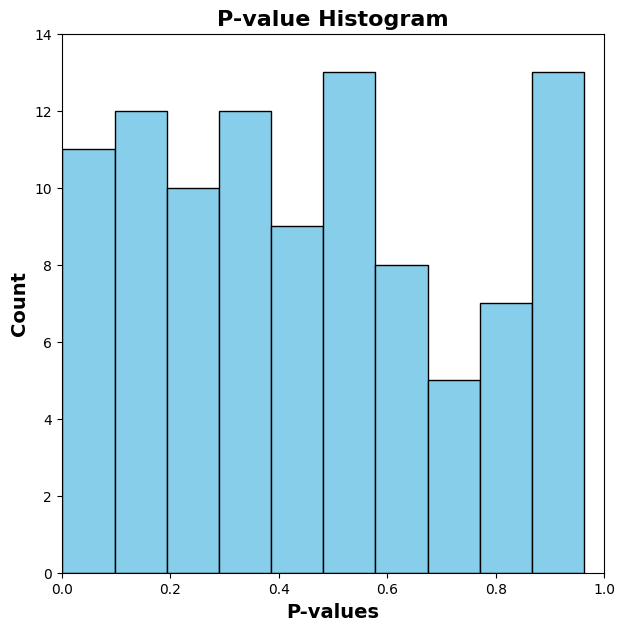

In [132]:
# Arguments for title and axis
title_args = {
    'fontsize': 16,
    'fontweight': 'bold'
}
axis_args = {
    'fontsize': 14,
    'fontweight': 'bold'
}

# Plot a histogram
plt.figure(figsize=(7,7))
plt.hist(pvalues, color='skyblue', edgecolor='black')
plt.title('P-value Histogram', **title_args)
plt.xlabel('P-values', **axis_args)
plt.xlim(0, 1)
plt.ylabel('Count', **axis_args)
plt.ylim(0, 14);

#### 8b)

In [133]:
# Reject null hypothesis at alpha=0.05
alpha = 0.05
rejected = [x for x in pvalues if x < alpha]
print(len(rejected))

4


At a significance level of $\alpha = 0.05$, we reject four null hypothesis.

#### 8c)

#### <u>Holm's Step-Down Method </u>

In [134]:
# Create a dataframe with relevant info
pvalues_rounded = [round(pvalue, 5) for pvalue in pvalues]
df = pd.DataFrame({'managers': range(m), 'p_values': pvalues_rounded})

# Holm's step-down method
alpha = 0.05
df_sorted = df.sort_values(by='p_values')
holm_thresholds = [(alpha / (m - i)) for i in range(m)]
holm_thresholds_rounded = [round(threshold, 5) for threshold in holm_thresholds]

# Add info to dataframe
holm_df = df_sorted.copy()
holm_df['holm_thresholds'] = holm_thresholds_rounded
holm_df.head()

,managers,p_values,holm_thresholds
14,14,0.00081,0.00050
44,44,0.00955,0.00051
39,39,0.02293,0.00051
27,27,0.03554,0.00052
72,72,0.05027,0.00052


In [135]:
# Reject null hypothesis based on holm's thresholds
coefs_holm = holm_df[
    holm_df['p_values'] < holm_df['holm_thresholds']
]
coefs_holm

,managers,p_values,holm_thresholds


Controlling the FWER at $\alpha = 0.05$ using Holm's method, we fail to reject any null hypothesis.

#### 8d)

#### <u>The Benjamini-Hochberg Procedure</u>


In [136]:
# Benjamini thresholds
alpha = 0.05
benjamini_thresholds = [round(alpha * ((1 + i) / m), 5) for i in range(m)]

# Add info to dataframe
benjamini_df = df_sorted.copy()
benjamini_df['benjamini_thresholds'] = benjamini_thresholds
benjamini_df.head()

,managers,p_values,benjamini_thresholds
14,14,0.00081,0.0005
44,44,0.00955,0.0010
39,39,0.02293,0.0015
27,27,0.03554,0.0020
72,72,0.05027,0.0025


In [137]:
# Reject null hypothesis based on benjamini's thresholds
coefs_benjamini = benjamini_df[
    benjamini_df['p_values'] < benjamini_df['benjamini_thresholds']
].copy()
coefs_benjamini

,managers,p_values,benjamini_thresholds


Controlling the FDR at $\alpha = 0.05$ using Benjamini-Hochberg's method, we fail to reject any null hypothesis.

#### 8e)

#### <u>Holm's Step-Down Method </u>

In [138]:
# 'Cherry-pick' top 10 funds
top10 = df_sorted.iloc[:10].copy()

# Holm's step down
m = 10
alpha = 0.05
holm_thresholds = [round((alpha / (m - i)), 5) for i in range(m)]
top10_holm = top10.copy()
top10_holm['holm_thresholds'] = holm_thresholds
top10_holm


,managers,p_values,holm_thresholds
14,14,0.00081,0.00500
44,44,0.00955,0.00556
39,39,0.02293,0.00625
27,27,0.03554,0.00714
72,72,0.05027,0.00833
0,0,0.05388,0.01000
50,50,0.06565,0.01250
20,20,0.07550,0.01667
9,9,0.07796,0.02500
35,35,0.08794,0.05000


In [139]:
# Rejecting null hypothesis based on Holm's method
top10_holm_coefs = top10_holm[
    top10_holm['p_values'] < top10_holm['holm_thresholds']
]
top10_holm_coefs

,managers,p_values,holm_thresholds
14,14,0.00081,0.005


When 'cherry-picking' the top 10 p-values coefficients and applying the Holm's step-down method, we are able to reject the null hypothesis of only one coefficient. (14th manager).

#### <u>The Benjamini-Hochberg Procedure</u>

In [140]:
# Benjamini
benjamini_thresholds = [round(alpha * ((i + 1) / m), 5) for i in range(m)]
top10_benjamini = top10.copy()
top10_benjamini['benjamini_thresolds'] = benjamini_thresholds
top10_benjamini

,managers,p_values,benjamini_thresolds
14,14,0.00081,0.005
44,44,0.00955,0.010
39,39,0.02293,0.015
27,27,0.03554,0.020
72,72,0.05027,0.025
0,0,0.05388,0.030
50,50,0.06565,0.035
20,20,0.07550,0.040
9,9,0.07796,0.045
35,35,0.08794,0.050


In [141]:
# Rejecting null hypothesis based on Benjamini's method
top10_benjamini_coefs = top10_benjamini[
    top10_benjamini['p_values'] < top10_benjamini['benjamini_thresolds']
]
top10_benjamini_coefs

,managers,p_values,benjamini_thresolds
14,14,0.00081,0.005
44,44,0.00955,0.010


When 'cherry-picking' the top 10 p-values coefficients and applying the Benjamini-Hochberg's method, we are able to reject the null hypothesis of two coefficient. (14th & 44th managers).

#### 8f)

The analysis in 8e) is statistically flawed. Multiple-testing correction methods are intended to be applied to the full set of hypothesis under consideration (all 100). Instead, the analysis 'cherry-picked' the 10 smallest p-values and applied the correction as an entire dataset, which artificially inflates the likelihood of rejecting the null hypothesis. The correct approach is to apply the correction method to the complete dataset of 100 hypotheses.